In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [3]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
# diabetics coubt
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [8]:
# Percentage of each class
df["Outcome"].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

In [9]:
# Checking whether zeros in column
cols_to_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols_to_check:
    zero_count = (df[col] == 0).sum()
    print(col, "has", zero_count, "zeros")

Glucose has 5 zeros
BloodPressure has 35 zeros
SkinThickness has 227 zeros
Insulin has 374 zeros
BMI has 11 zeros


In [10]:
# First, turn 0 into NaN (missing)
# Then fill missing values with median of that column
for col in cols_to_check:
    df[col] = df[col].replace(0, np.nan)
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

In [11]:
# Checking zeros again 
for col in cols_to_check:
    zero_count = (df[col] == 0).sum()
    print(col, "has", zero_count, "zeros after cleaning")

# Let's save this clean dataset
df.to_csv("diabetes_clean.csv", index=False)

Glucose has 0 zeros after cleaning
BloodPressure has 0 zeros after cleaning
SkinThickness has 0 zeros after cleaning
Insulin has 0 zeros after cleaning
BMI has 0 zeros after cleaning


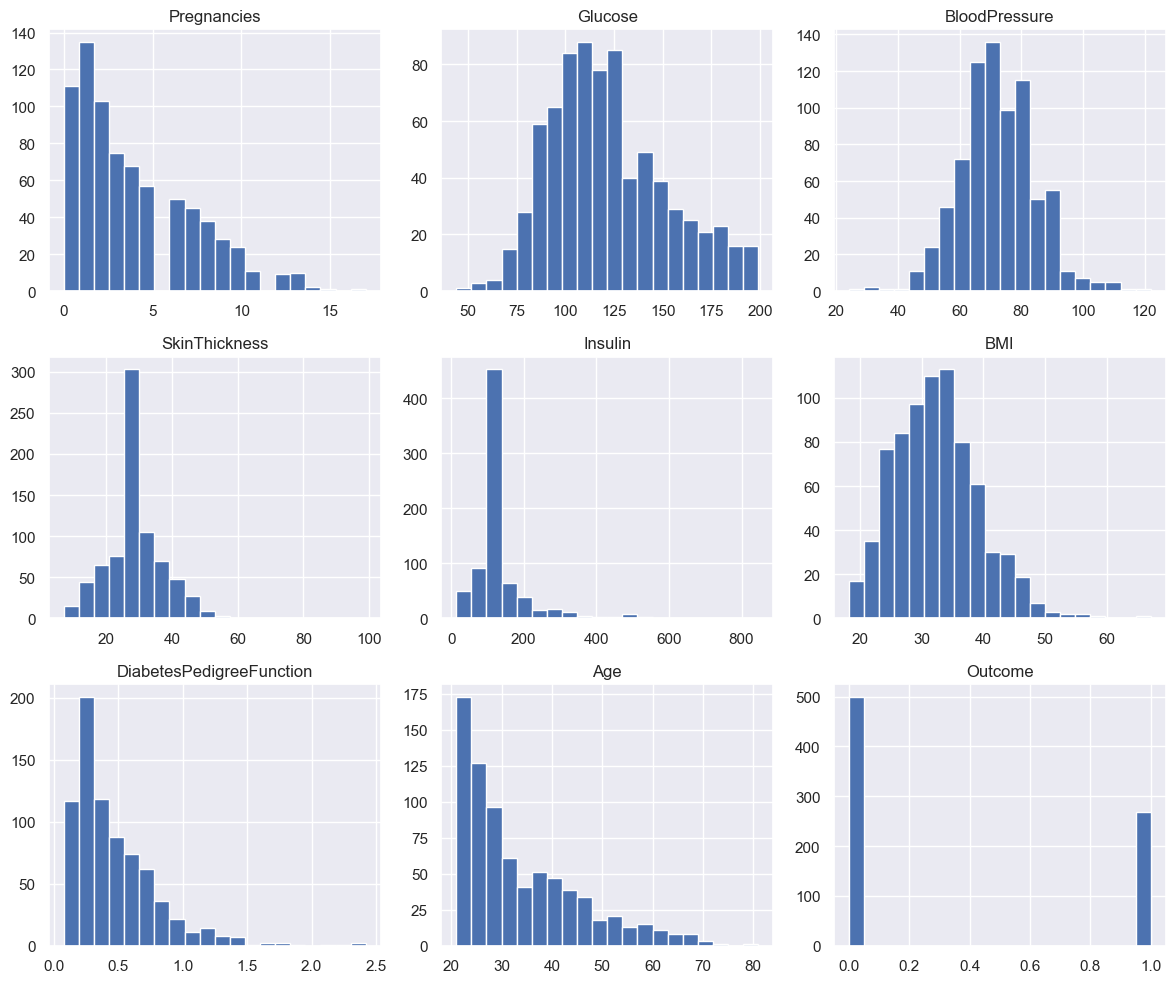

In [12]:
# Histogram
df.hist(bins=20, figsize=(12, 10))
plt.tight_layout()
plt.show()

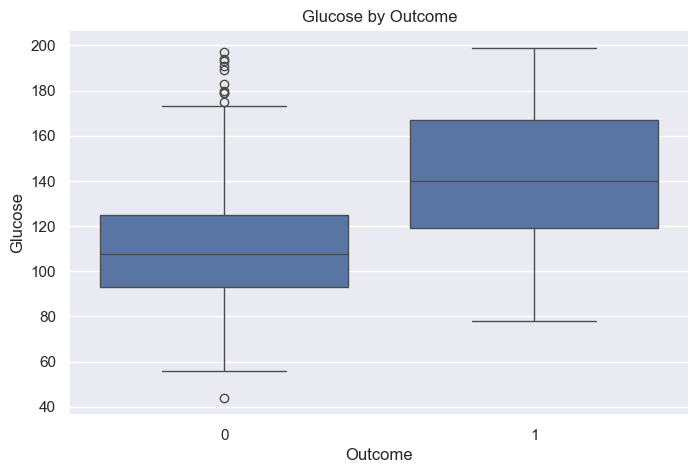

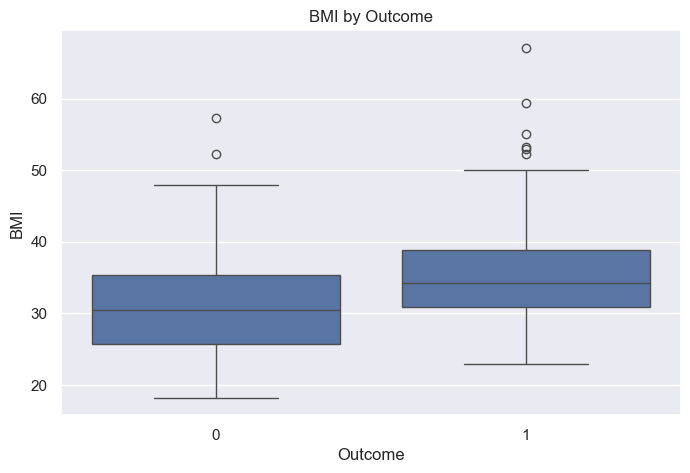

In [13]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Outcome', y='Glucose')
plt.title("Glucose by Outcome")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Outcome", y="BMI")
plt.title("BMI by Outcome")
plt.show()

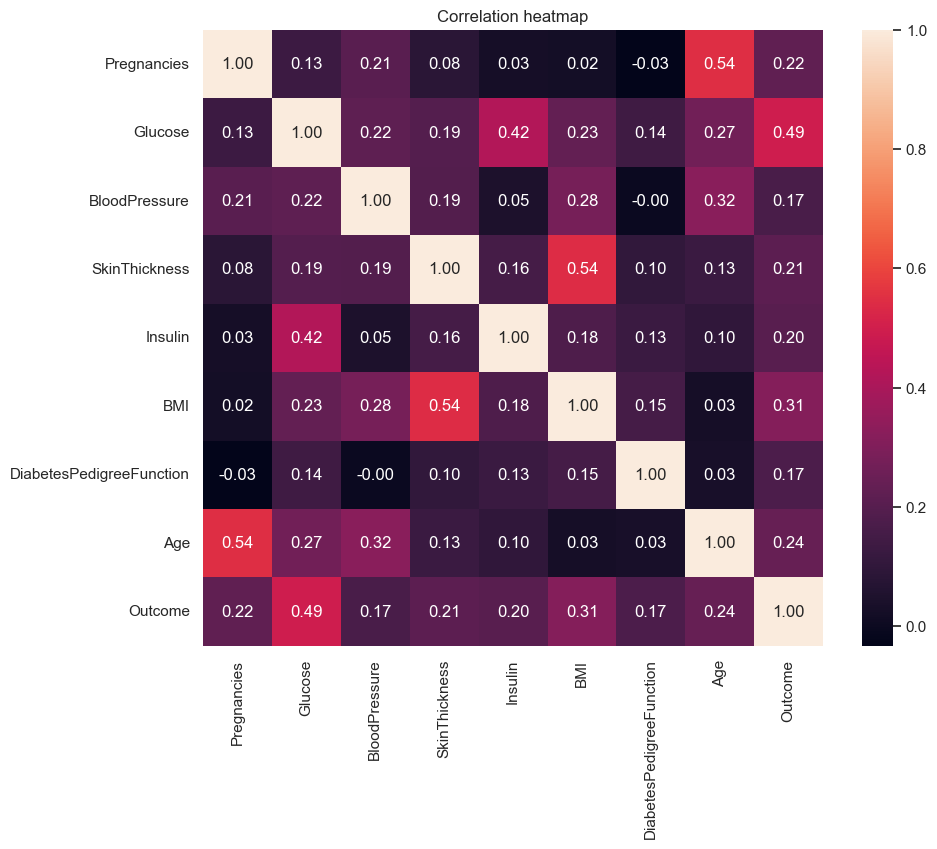

In [14]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation heatmap")
plt.show()